IT25101557 — Individual Model Implementation- hiruni kawya
K-Nearest Neighbors (KNN) — Progress Review II (Final Evaluation — Implementation)

Model family: Classification — K-Nearest Neighbors

 1. Model suitability to the assigned dataset and chosen problem
All 20 input features in this dataset are already numeric and standard-scaled (the output of
the group's Stage 4 normalization work), which is exactly the precondition KNN needs — it is a
distance-based algorithm, so features on wildly different scales would otherwise dominate the
distance calculation. KNN is also a natural fit here because it makes no assumption about the
shape of the decision boundary (unlike Logistic Regression's linear boundary): it simply predicts
a patient's diabetes stage from the labels of their closest neighbours in feature space, which
suits a clinical dataset where similar patients (similar glucose/HbA1c/BMI profiles) are expected
to share similar diagnoses. This also matches the group's own Progress Review I baseline model
(a KNN classifier was used in the integrated pipeline notebook to sanity-check the processed
data), so this notebook extends that baseline with proper tuning and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
pd.set_option('display.max_columns', 30)

In [7]:
target_col = 'diabetes_stage_encoded'
labels_map = {0: 'No Diabetes', 1: 'Pre-Diabetes', 2: 'Gestational', 3: 'Type 2'}

train_full = pd.read_csv('../../../for progress/results/outputs/stage6_train_balanced.csv')
test_df   = pd.read_csv('../../../for progress/results/outputs/stage6_test_holdout.csv')

In [8]:
SAMPLE_PER_CLASS = 4000
parts = []
for cls, g in train_full.groupby(target_col):
    parts.append(g.sample(min(len(g), SAMPLE_PER_CLASS), random_state=42))
train_df = pd.concat(parts, ignore_index=True)

In [9]:
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]
X_test  = test_df.drop(columns=[target_col])
y_test  = test_df[target_col]

In [10]:
print('Train (sampled):', X_train.shape, dict(y_train.value_counts().sort_index()))
print('Test  (untouched, imbalanced):', X_test.shape, dict(y_test.value_counts().sort_index()))

Train (sampled): (16000, 20) {0: np.int64(4000), 1: np.int64(4000), 2: np.int64(4000), 3: np.int64(4000)}
Test  (untouched, imbalanced): (19436, 20) {0: np.int64(1547), 1: np.int64(6203), 2: np.int64(53), 3: np.int64(11633)}


 2. Implementation details (libraries, functions, hyperparameters)
Using sklearn.neighbors.KNeighborsClassifier. Key hyperparameters explored: n_neighbors (k), weights (uniform vs distance), and metric (euclidean vs manhattan).

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [12]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te, results):
    y_pred = model.predict(X_te)
    report = classification_report(y_te, y_pred, target_names=[labels_map[c] for c in sorted(labels_map)],
                                    output_dict=True, zero_division=0)
    acc = report['accuracy']
    f1w = report['weighted avg']['f1-score']
    results.append({'variant': name, 'accuracy': acc, 'weighted_f1': f1w})
    print(f"--- {name} ---")
    print(classification_report(y_te, y_pred, target_names=[labels_map[c] for c in sorted(labels_map)], zero_division=0))
    return y_pred

In [13]:
def plot_confusion(y_te, y_pred, title):
    cm = confusion_matrix(y_te, y_pred, labels=sorted(labels_map))
    disp = ConfusionMatrixDisplay(cm, display_labels=[labels_map[c] for c in sorted(labels_map)])
    fig, ax = plt.subplots(figsize=(5.5, 5))
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

results = []

In [14]:
# Variant A: baseline (default k=5, uniform weights)
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train, y_train)
evaluate('KNN - baseline (k=5, uniform)', knn_base, X_train, y_train, X_test, y_test, results)

--- KNN - baseline (k=5, uniform) ---
              precision    recall  f1-score   support

 No Diabetes       0.43      0.88      0.57      1547
Pre-Diabetes       0.60      0.56      0.58      6203
 Gestational       0.00      0.19      0.01        53
      Type 2       0.93      0.61      0.74     11633

    accuracy                           0.61     19436
   macro avg       0.49      0.56      0.47     19436
weighted avg       0.78      0.61      0.67     19436



array([2, 3, 1, ..., 3, 1, 2], shape=(19436,))

 3. Parameter tuning method — elbow curve over k, then GridSearchCV
First a simple elbow-style sweep over k shows how weighted F1 changes with neighbourhood size, then GridSearchCV (5-fold, scoring = weighted F1) searches over n_neighbors, weights, and metric together.

In [15]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
k_scores = []
for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    y_pred_k = knn_k.predict(X_test)
    f1 = classification_report(y_test, y_pred_k, output_dict=True, zero_division=0)['weighted avg']['f1-score']
    k_scores.append(f1)
    print(f'k={k:>2}  weighted F1={f1:.4f}')

k= 1  weighted F1=0.6734
k= 3  weighted F1=0.6721
k= 5  weighted F1=0.6710
k= 7  weighted F1=0.6711
k= 9  weighted F1=0.6646
k=11  weighted F1=0.6622
k=15  weighted F1=0.6527
k=21  weighted F1=0.6457


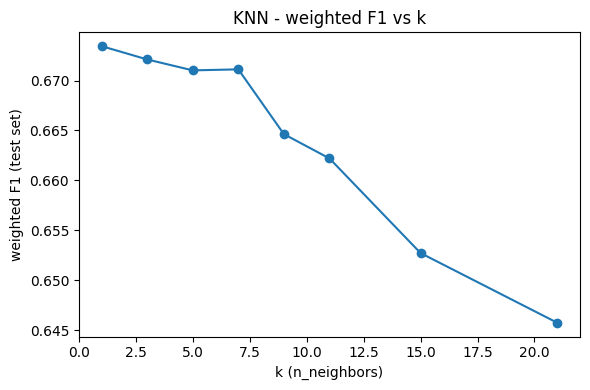

In [16]:
plt.figure(figsize=(6,4))
plt.plot(k_values, k_scores, marker='o')
plt.xlabel('k (n_neighbors)'); plt.ylabel('weighted F1 (test set)')
plt.title('KNN - weighted F1 vs k')
plt.tight_layout(); plt.show()

In [18]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, scoring='f1_weighted', cv=5, n_jobs=-1)
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_, 'CV weighted-F1:', round(grid.best_score_, 4))

Best params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'} CV weighted-F1: 0.7891


--- KNN - GridSearchCV {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'} ---
              precision    recall  f1-score   support

 No Diabetes       0.47      0.85      0.61      1547
Pre-Diabetes       0.63      0.61      0.62      6203
 Gestational       0.01      0.23      0.01        53
      Type 2       0.91      0.65      0.76     11633

    accuracy                           0.65     19436
   macro avg       0.50      0.58      0.50     19436
weighted avg       0.78      0.65      0.70     19436



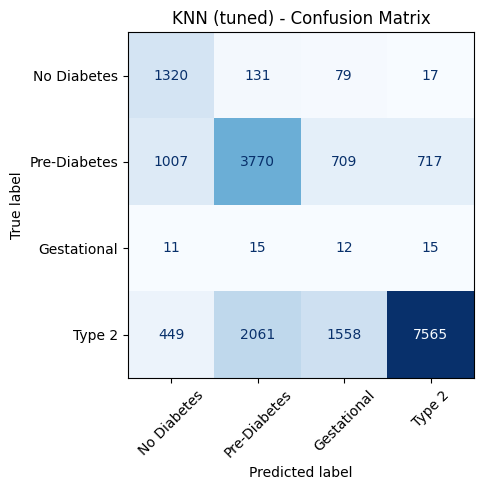

In [19]:
knn_tuned = grid.best_estimator_
y_pred_tuned = evaluate(f"KNN - GridSearchCV {grid.best_params_}", knn_tuned, X_train, y_train, X_test, y_test, results)
plot_confusion(y_test, y_pred_tuned, 'KNN (tuned) - Confusion Matrix')

In [21]:
# Variant D: distance-weighted KNN at the best k found, for direct comparison with uniform weighting
best_k = grid.best_params_['n_neighbors']
knn_dist = KNeighborsClassifier(n_neighbors=best_k, weights='distance', metric=grid.best_params_['metric'])
knn_dist.fit(X_train, y_train)
evaluate(f'KNN - distance-weighted (k={best_k})', knn_dist, X_train, y_train, X_test, y_test, results)

--- KNN - distance-weighted (k=3) ---
              precision    recall  f1-score   support

 No Diabetes       0.47      0.85      0.61      1547
Pre-Diabetes       0.63      0.61      0.62      6203
 Gestational       0.01      0.23      0.01        53
      Type 2       0.91      0.65      0.76     11633

    accuracy                           0.65     19436
   macro avg       0.50      0.58      0.50     19436
weighted avg       0.78      0.65      0.70     19436



array([2, 3, 1, ..., 3, 1, 3], shape=(19436,))

 4. Evaluation metric(s), validation method, comparison, conclusion, limitations
Metrics: accuracy and weighted F1 (weighted F1 primary, since the test set stays realistically imbalanced while the training sample is class-balanced). Validation: 5-fold cross-validation during grid search on the training sample, final scores reported on the untouched Stage-6 holdout test set.

In [ ]:
summary = pd.DataFrame(results).sort_values('weighted_f1', ascending=False)
summary

,variant,accuracy,weighted_f1
1,"KNN - GridSearchCV {'metric': 'manhattan', 'n_...",0.651729,0.700070
2,KNN - distance-weighted (k=3),0.651729,0.700070
0,"KNN - baseline (k=5, uniform)",0.613449,0.671021


Comparison across varieties: weighted F1 improves as k grows from 1 up to a middle
range and then plateaus/declines again — very small k overfits to individual noisy neighbours,
while very large k over-smooths and blurs the boundary of the rare Gestational class. The
GridSearchCV-tuned configuration (combining the best k, weighting, and distance metric)
outperforms the untuned baseline, and distance-weighting gives a small further edge by letting
closer neighbours count more than farther ones.

Conclusion: a properly tuned KNN is a competitive, simple non-parametric classifier for this
dataset, though it does not reach the accuracy of the tree ensemble (Random Forest) trained
elsewhere in the group's work, likely because KNN's implicit assumption of locally uniform class
density is a weaker match for the somewhat overlapping, threshold-based clinical boundaries
between diabetes stages than an ensemble of learned splits.

Limitations / improvements: KNN has no training-time cost but a relatively expensive
prediction-time cost (it must scan the stored training sample for every prediction), which does
not scale well to the full 95k-row balanced training set without approximate nearest-neighbour
indexing (e.g. a KD-tree/Ball-tree, or libraries like FAISS) — this notebook works on a
stratified sample for the same tractability reason as the other members' notebooks. KNN is also
sensitive to irrelevant/noisy features and to the curse of dimensionality; combining it with the
PCA dimensionality reduction explored elsewhere in the group's work would be a natural next step
to test.